# Global Commodities Intelligence Platform - Data Mining & Visualization

This notebook analyzes commodity prices from the **Gold layer** of the data warehouse (MySQL).

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

load_dotenv()
DB_URL = os.getenv('DB_URL')
if not DB_URL:
    raise ValueError('DB_URL not found in .env')

engine = create_engine(DB_URL)
IMAGE_DIR = 'notebook/plots'
if not os.path.exists(IMAGE_DIR):
    IMAGE_DIR = '../notebook/plots'
os.makedirs(IMAGE_DIR, exist_ok=True)

query = '''
SELECT
    c.commodity_name,
    t.full_timestamp AS timestamp,
    f.price_usd
FROM fact_commodity_price f
JOIN dim_commodity c ON f.commodity_id = c.commodity_id
JOIN dim_time t ON f.time_id = t.time_id
ORDER BY t.full_timestamp, c.commodity_name
'''

df = pd.read_sql(query, engine)
df['timestamp'] = pd.to_datetime(df['timestamp'])

print('Rows loaded:', len(df))
print(df.head())

Rows loaded: 118
  commodity_name           timestamp  price_usd
0       Aluminum 2026-03-20 13:16:00  3146.7500
1    Brent Crude 2026-03-20 13:32:00   104.6600
2         Copper 2026-03-20 13:32:00     5.4115
3      Crude Oil 2026-03-20 13:32:00    95.5500
4           Gold 2026-03-20 13:32:00  4656.7998


## Line Chart - Commodity Price Trend
This shows how commodity prices change over time for each tracked commodity.

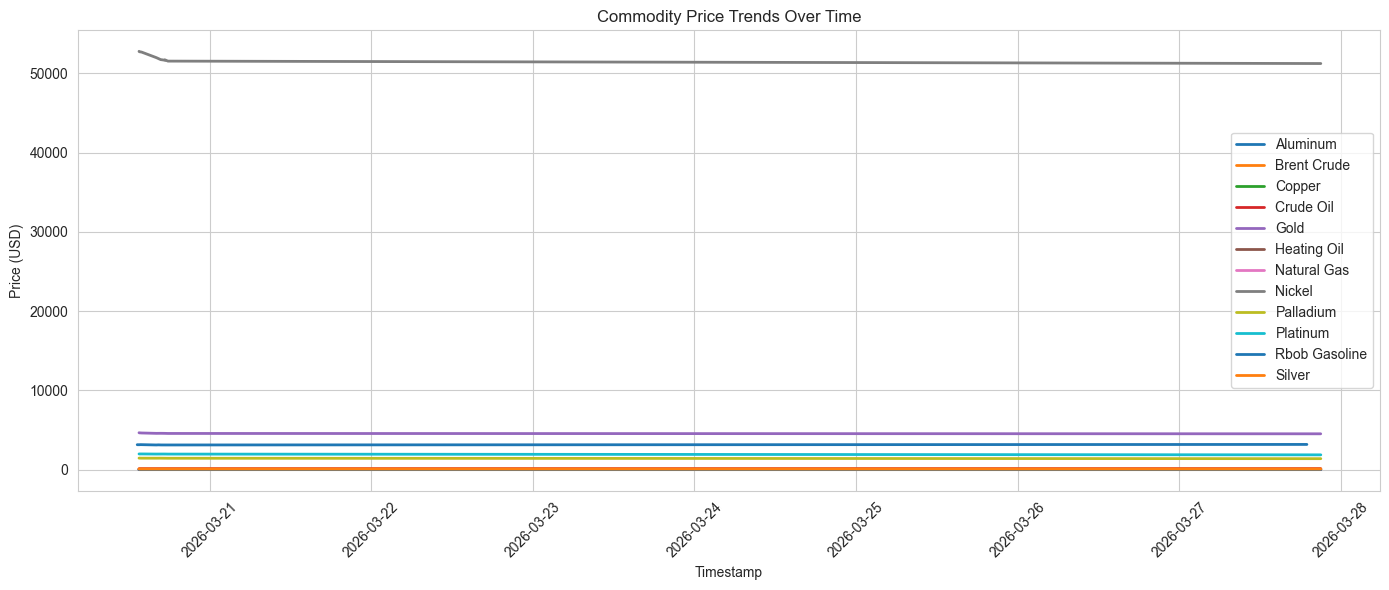

In [34]:
plt.figure(figsize=(14, 6))
for commodity in df['commodity_name'].unique():
    commodity_df = df[df['commodity_name'] == commodity]
    plt.plot(commodity_df['timestamp'], commodity_df['price_usd'], label=commodity, linewidth=2)

plt.title('Commodity Price Trends Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{IMAGE_DIR}/line_chart_commodity_price_trends.png", dpi=200)
plt.show()

## Bar Chart - Latest Commodity Price Comparison
This compares the most recent USD price for each commodity.

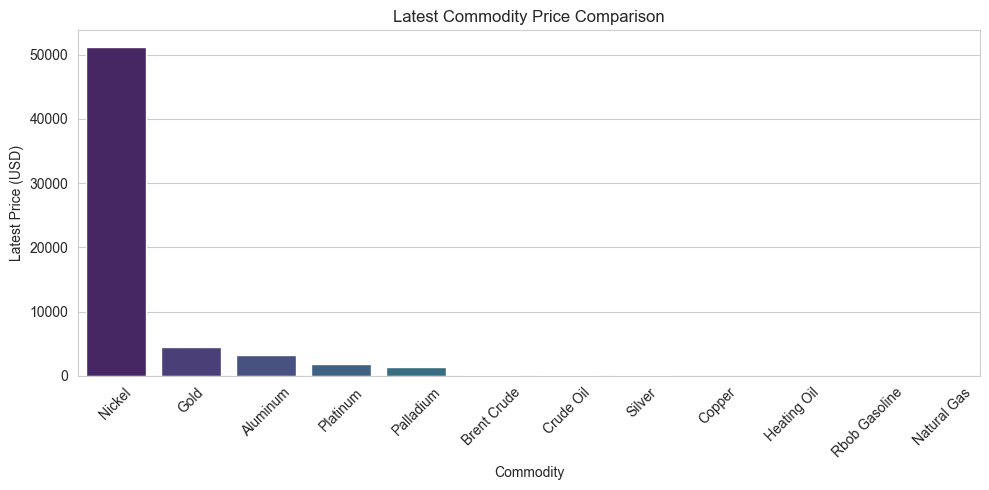

,commodity_name,price_usd,timestamp
113,Nickel,51235.0000,2026-03-27 20:59:00
107,Gold,4520.5000,2026-03-27 20:58:00
106,Aluminum,3180.0000,2026-03-27 18:55:00
115,Platinum,1866.4000,2026-03-27 20:59:00
114,Palladium,1384.5000,2026-03-27 20:59:00
110,Brent Crude,106.8400,2026-03-27 20:59:00
112,Crude Oil,101.1800,2026-03-27 20:59:00
117,Silver,69.7700,2026-03-27 20:59:00
111,Copper,5.4615,2026-03-27 20:59:00
108,Heating Oil,4.3203,2026-03-27 20:58:00


In [35]:
latest_df = (
    df.sort_values('timestamp')
      .groupby('commodity_name', as_index=False)
      .tail(1)
      .sort_values('price_usd', ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=latest_df, x='commodity_name', y='price_usd', hue='commodity_name', palette='viridis', legend=False)
plt.title('Latest Commodity Price Comparison')
plt.xlabel('Commodity')
plt.ylabel('Latest Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{IMAGE_DIR}/bar_chart_latest_commodity_price_comparison.png", dpi=200)
plt.show()

latest_df[['commodity_name', 'price_usd', 'timestamp']]

## Heatmap - Commodity Correlation
This shows correlation between commodity prices to identify movement relationships.

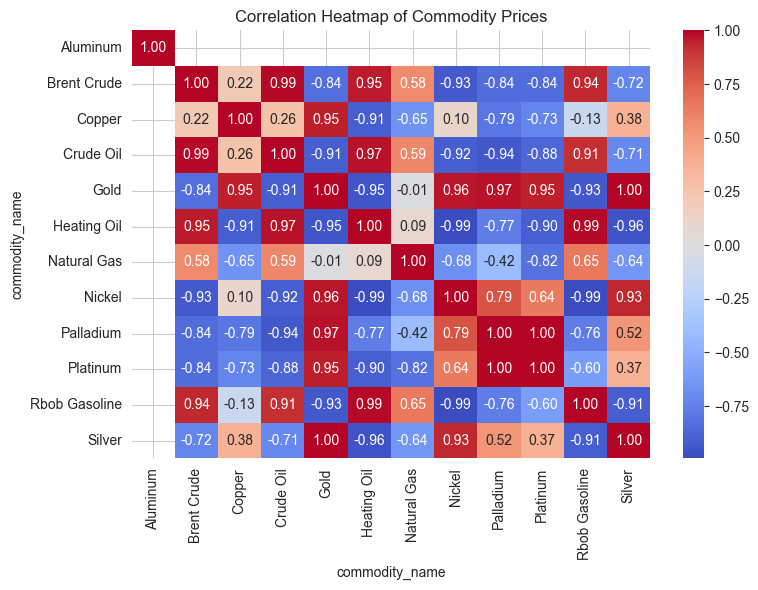

In [36]:
pivot_df = df.pivot_table(index='timestamp', columns='commodity_name', values='price_usd', aggfunc='mean')
corr_df = pivot_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Commodity Prices')
plt.tight_layout()
plt.savefig(f"{IMAGE_DIR}/heatmap_commodity_correlation.png", dpi=200)
plt.show()

## Histogram - Price Distribution
This shows the distribution of prices for each commodity.

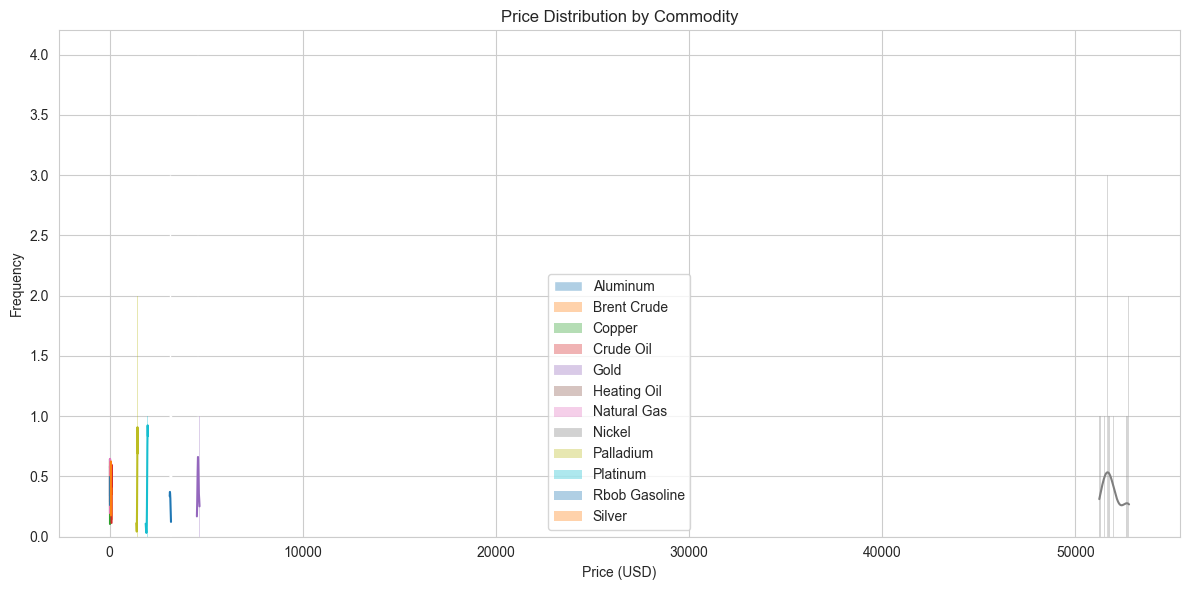

In [37]:
plt.figure(figsize=(12, 6))
for commodity in df['commodity_name'].unique():
    sns.histplot(
        df[df['commodity_name'] == commodity]['price_usd'],
        bins=20,
        kde=True,
        label=commodity,
        alpha=0.35
    )

plt.title('Price Distribution by Commodity')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig(f"{IMAGE_DIR}/histogram_price_distribution_by_commodity.png", dpi=200)
plt.show()